In [1]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category=warn)

import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from typing import List, Tuple, Optional
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
device = torch.device("mps")
print(f"Device: {device}")


PyTorch: 2.10.0
Torchvision: 0.25.0
Device: mps


## Реализация xLSTM

In [2]:
class CausalConv1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1, **kwargs):
        super(CausalConv1D, self).__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=self.padding,
            dilation=dilation,
            **kwargs,
        )

    def forward(self, x):
        x = self.conv(x)
        return x[:, :, : -self.padding]


class BlockDiagonal(nn.Module):
    def __init__(self, in_features, out_features, num_blocks):
        super(BlockDiagonal, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_blocks = num_blocks

        assert out_features % num_blocks == 0

        block_out_features = out_features // num_blocks

        self.blocks = nn.ModuleList(
            [nn.Linear(in_features, block_out_features) for _ in range(num_blocks)]
        )

    def forward(self, x):
        x = [block(x) for block in self.blocks]
        x = torch.cat(x, dim=-1)
        return x


class sLSTMBlock(nn.Module):
    def __init__(self, input_size, head_size, num_heads, proj_factor=4 / 3):
        super(sLSTMBlock, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.proj_factor = proj_factor

        assert proj_factor > 0

        self.layer_norm = nn.LayerNorm(input_size)
        self.causal_conv = CausalConv1D(1, 1, 4)

        self.Wz = BlockDiagonal(input_size, self.hidden_size, num_heads)
        self.Wi = BlockDiagonal(input_size, self.hidden_size, num_heads)
        self.Wf = BlockDiagonal(input_size, self.hidden_size, num_heads)
        self.Wo = BlockDiagonal(input_size, self.hidden_size, num_heads)

        self.Rz = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)
        self.Ri = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)
        self.Rf = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)
        self.Ro = BlockDiagonal(self.hidden_size, self.hidden_size, num_heads)

        self.group_norm = nn.GroupNorm(num_heads, self.hidden_size)

        self.up_proj_left = nn.Linear(
            self.hidden_size, int(self.hidden_size * proj_factor)
        )
        self.up_proj_right = nn.Linear(
            self.hidden_size, int(self.hidden_size * proj_factor)
        )
        self.down_proj = nn.Linear(int(self.hidden_size * proj_factor), input_size)

    def forward(self, x, prev_state):
        assert x.size(-1) == self.input_size
        h_prev, c_prev, n_prev, m_prev = prev_state

        h_prev = h_prev.to(x.device)
        c_prev = c_prev.to(x.device)
        n_prev = n_prev.to(x.device)
        m_prev = m_prev.to(x.device)

        x_norm = self.layer_norm(x)
        x_conv = F.silu(self.causal_conv(x_norm.unsqueeze(1)).squeeze(1))

        z = torch.tanh(self.Wz(x_norm) + self.Rz(h_prev))
        o = torch.sigmoid(self.Wo(x_norm) + self.Ro(h_prev))
        i_tilde = self.Wi(x_conv) + self.Ri(h_prev)
        f_tilde = self.Wf(x_conv) + self.Rf(h_prev)

        m_t = torch.max(f_tilde + m_prev, i_tilde)
        i = torch.exp(i_tilde - m_t)  # Всегда <= 1.0
        f = torch.exp(f_tilde + m_prev - m_t)  # Всегда <= 1.0

        c_t = f * c_prev + i * z
        n_t = f * n_prev + i
        h_t = o * c_t / n_t

        output = h_t
        output_norm = self.group_norm(output)
        output_left = self.up_proj_left(output_norm)
        output_right = self.up_proj_right(output_norm)
        output_gated = F.gelu(output_right)
        output = output_left * output_gated
        output = self.down_proj(output)
        final_output = output + x

        return final_output, (h_t, c_t, n_t, m_t)


class sLSTM(nn.Module):
    # Add bias, dropout, bidirectional
    def __init__(
        self,
        input_size,
        head_size,
        num_heads,
        num_layers=1,
        batch_first=False,
        proj_factor=4 / 3,
    ):
        super(sLSTM, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor

        self.layers = nn.ModuleList(
            [
                sLSTMBlock(input_size, head_size, num_heads, proj_factor)
                for _ in range(num_layers)
            ]
        )

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first:
            x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()

        if state is not None:
            state = torch.stack(list(state)).to(x.device)
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = (
                state.size()
            )
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(
                self.num_layers, 4, batch_size, self.hidden_size, device=x.device
            )

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)

        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state


class mLSTMBlock(nn.Module):
    def __init__(self, input_size, head_size, num_heads, proj_factor=2):
        super(mLSTMBlock, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.proj_factor = proj_factor

        assert proj_factor > 0

        self.layer_norm = nn.LayerNorm(input_size)
        self.up_proj_left = nn.Linear(input_size, int(input_size * proj_factor))
        self.up_proj_right = nn.Linear(input_size, self.hidden_size)
        self.down_proj = nn.Linear(self.hidden_size, input_size)

        self.causal_conv = CausalConv1D(1, 1, 4)
        self.skip_connection = nn.Linear(
            int(input_size * proj_factor), self.hidden_size
        )

        self.Wq = BlockDiagonal(
            int(input_size * proj_factor), self.hidden_size, num_heads
        )
        self.Wk = BlockDiagonal(
            int(input_size * proj_factor), self.hidden_size, num_heads
        )
        self.Wv = BlockDiagonal(
            int(input_size * proj_factor), self.hidden_size, num_heads
        )
        self.Wi = nn.Linear(int(input_size * proj_factor), self.hidden_size)
        self.Wf = nn.Linear(int(input_size * proj_factor), self.hidden_size)
        self.Wo = nn.Linear(int(input_size * proj_factor), self.hidden_size)

        self.group_norm = nn.GroupNorm(num_heads, self.hidden_size)

    def forward(self, x, prev_state):
        h_prev, c_prev, n_prev, m_prev = prev_state

        h_prev = h_prev.to(x.device)
        c_prev = c_prev.to(x.device)
        n_prev = n_prev.to(x.device)
        m_prev = m_prev.to(x.device)

        assert x.size(-1) == self.input_size
        x_norm = self.layer_norm(x)
        x_up_left = self.up_proj_left(x_norm)
        x_up_right = self.up_proj_right(x_norm)

        x_conv = F.silu(self.causal_conv(x_up_left.unsqueeze(1)).squeeze(1))
        x_skip = self.skip_connection(x_conv)

        q = self.Wq(x_conv)
        k = self.Wk(x_conv) / (self.head_size**0.5)
        v = self.Wv(x_up_left)

        i_tilde = self.Wi(x_conv)
        f_tilde = self.Wf(x_conv)
        o = torch.sigmoid(self.Wo(x_up_left))

        m_t = torch.max(f_tilde + m_prev, i_tilde)
        i = torch.exp(i_tilde - m_t)
        f = torch.exp(f_tilde + m_prev - m_t)

        # тут кусок я чуть-чуть заменил, чтобы у меня батчи не смешивались и не было деления на 0
        c_t = f * c_prev + i * (v * k)
        n_t = f * n_prev + i * k
        denom = torch.abs((n_t * q).sum(dim=-1, keepdim=True)) + 1e-6
        h_t = o * (c_t * q) / denom

        output = h_t
        output_norm = self.group_norm(output)
        output = output_norm + x_skip
        output = output * F.silu(x_up_right)
        output = self.down_proj(output)
        final_output = output + x

        return final_output, (h_t, c_t, n_t, m_t)


class mLSTM(nn.Module):
    # Add bias, dropout, bidirectional
    def __init__(
        self,
        input_size,
        head_size,
        num_heads,
        num_layers=1,
        batch_first=False,
        proj_factor=2,
    ):
        super(mLSTM, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.num_layers = num_layers
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor

        self.layers = nn.ModuleList(
            [
                mLSTMBlock(input_size, head_size, num_heads, proj_factor)
                for _ in range(num_layers)
            ]
        )

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first:
            x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()

        if state is not None:
            state = torch.stack(list(state)).to(x.device)
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = (
                state.size()
            )
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(
                self.num_layers, 4, batch_size, self.hidden_size, device=x.device
            )

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)

        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state


class xLSTM(nn.Module):
    # Add bias, dropout, bidirectional
    def __init__(
        self,
        input_size,
        head_size,
        num_heads,
        layers,
        batch_first=False,
        proj_factor_slstm=4 / 3,
        proj_factor_mlstm=2,
    ):
        super(xLSTM, self).__init__()
        self.input_size = input_size
        self.head_size = head_size
        self.hidden_size = head_size * num_heads
        self.num_heads = num_heads
        self.layers = layers
        self.num_layers = len(layers)
        self.batch_first = batch_first
        self.proj_factor_slstm = proj_factor_slstm
        self.proj_factor_mlstm = proj_factor_mlstm

        self.layers = nn.ModuleList()
        for layer_type in layers:
            if layer_type == "s":
                layer = sLSTMBlock(input_size, head_size, num_heads, proj_factor_slstm)
            elif layer_type == "m":
                layer = mLSTMBlock(input_size, head_size, num_heads, proj_factor_mlstm)
            else:
                raise ValueError(f"Invalid layer type")
            self.layers.append(layer)

    def forward(self, x, state=None):
        assert x.ndim == 3
        if self.batch_first:
            x = x.transpose(0, 1)
        seq_len, batch_size, _ = x.size()

        if state is not None:
            state = torch.stack(list(state)).to(x.device)
            assert state.ndim == 4
            num_hidden, state_num_layers, state_batch_size, state_input_size = (
                state.size()
            )
            assert num_hidden == 4
            assert state_num_layers == self.num_layers
            assert state_batch_size == batch_size
            assert state_input_size == self.input_size
            state = state.transpose(0, 1)
        else:
            state = torch.zeros(
                self.num_layers, 4, batch_size, self.hidden_size, device=x.device
            )

        output = []
        for t in range(seq_len):
            x_t = x[t]
            for layer in range(self.num_layers):
                x_t, state_tuple = self.layers[layer](x_t, tuple(state[layer].clone()))
                state[layer] = torch.stack(list(state_tuple))
            output.append(x_t)

        output = torch.stack(output)
        if self.batch_first:
            output = output.transpose(0, 1)
        state = tuple(state.transpose(0, 1))
        return output, state


In [3]:
class GateCapture:
    def __init__(self, xlstm_module):
        self.xlstm = xlstm_module
        self.gates = []
        self._saved = []

    def __enter__(self):
        self.gates = [{"f": [], "i": [], "o": []} for _ in self.xlstm.layers]

        for l_idx, layer in enumerate(self.xlstm.layers):
            orig = layer.forward
            is_slstm = isinstance(layer, sLSTMBlock)

            def make_wrapper(orig_fn, idx, slstm, lyr):
                def wrapper(x, prev_state):
                    h_prev, c_prev, n_prev, m_prev = [s.to(x.device) for s in prev_state]

                    if slstm:
                        x_norm = lyr.layer_norm(x)
                        x_conv = F.silu(lyr.causal_conv(x_norm.unsqueeze(1)).squeeze(1))
                        i_tilde = lyr.Wi(x_conv) + lyr.Ri(h_prev)
                        f_tilde = lyr.Wf(x_conv) + lyr.Rf(h_prev)
                        o_val = torch.sigmoid(lyr.Wo(x_norm) + lyr.Ro(h_prev))
                    else:
                        x_norm = lyr.layer_norm(x)
                        x_up_left = lyr.up_proj_left(x_norm)
                        x_conv = F.silu(lyr.causal_conv(x_up_left.unsqueeze(1)).squeeze(1))
                        i_tilde = lyr.Wi(x_conv)
                        f_tilde = lyr.Wf(x_conv)
                        o_val = torch.sigmoid(lyr.Wo(x_up_left))

                    m_t = torch.max(f_tilde + m_prev, i_tilde)
                    f_val = torch.exp(f_tilde + m_prev - m_t)
                    i_val = torch.exp(i_tilde - m_t)

                    self.gates[idx]["f"].append(f_val.detach().cpu())
                    self.gates[idx]["i"].append(i_val.detach().cpu())
                    self.gates[idx]["o"].append(o_val.detach().cpu())

                    return orig_fn(x, prev_state)
                return wrapper

            layer.forward = make_wrapper(orig, l_idx, is_slstm, layer)
            self._saved.append((layer, orig))

        return self

    def __exit__(self, *args):
        for layer, orig in self._saved:
            layer.forward = orig
        self._saved.clear()

    def get_stacked(self):
        return [
            {k: torch.stack(v, dim=0) for k, v in lg.items()}
            for lg in self.gates
        ]


## Датасет: Intel Image Classification

Датасет из первого дз

### Vision-xLSTM

Изображения обрабатываются как последовательности патчей

$$\text{img} \in \mathbb{R}^{H \times W \times C} \xrightarrow{\text{патчи } P \times P} \text{seq} \in \mathbb{R}^{N \times (P^2 C)}$$

- Разрешение: 64×64 RGB
- Размер патча: 8×8 -> $N = 64$ патча на изображение


Патчей на изображение: 64
Размерность патча: 192
Длина последовательности: 64
Классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 14034, Test: 3000


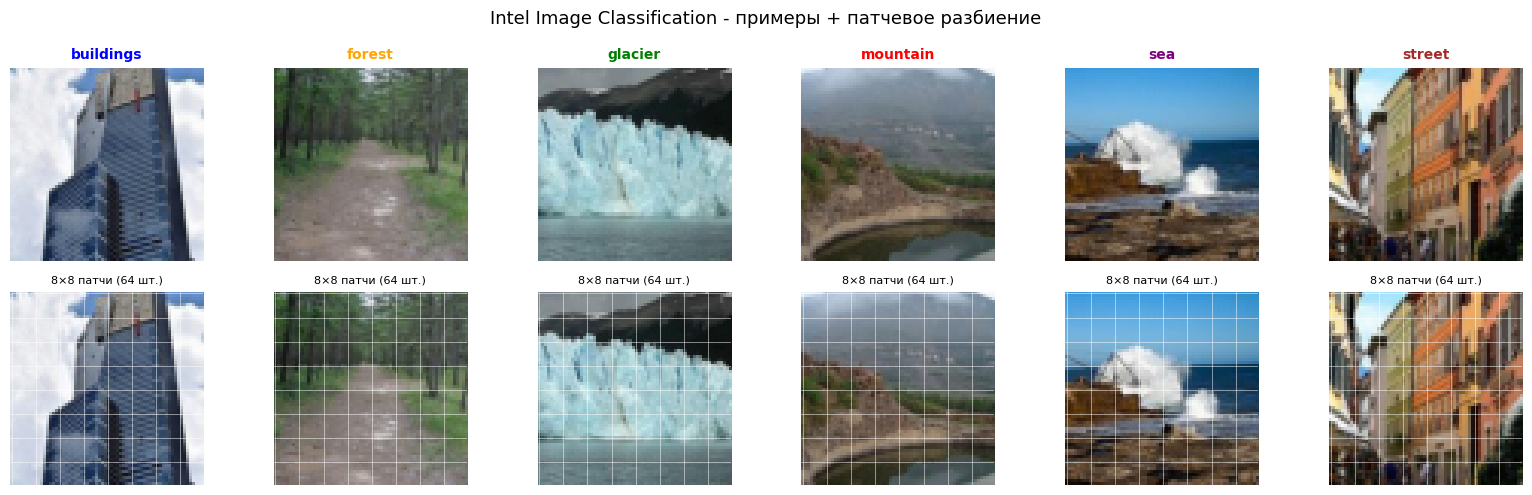

In [4]:
img_size = 64
patch_size = 8
n_patches = (img_size // patch_size) ** 2
patch_dim = patch_size * patch_size * 3
seq_len = n_patches
n_classes = 6
batch_size = 64

data_root = "/Users/ivanpetrusa/Desktop/DL/HSE_Fundamentals_of_DL_2026/HW/data/intel_images"

print(f"Патчей на изображение: {n_patches}")
print(f"Размерность патча: {patch_dim}")
print(f"Длина последовательности: {seq_len}")

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])
test_tf = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = ImageFolder(os.path.join(data_root, "train"), transform=train_tf)
test_ds = ImageFolder(os.path.join(data_root, "test"), transform=test_tf)

class_names_list = train_ds.classes
print(f"Классы: {class_names_list}")
print(f"Train: {len(train_ds)}, Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

def img_to_patches(imgs: torch.Tensor) -> torch.Tensor:
    B, C, H, W = imgs.shape
    p = patch_size
    x = imgs.reshape(B, C, H // p, p, W // p, p)
    x = x.permute(0, 2, 4, 3, 5, 1)
    x = x.reshape(B, (H // p) * (W // p), p * p * C)
    return x

colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
fig, axes = plt.subplots(2, 6, figsize=(16, 5))
inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)
for cls_idx, cls_name in enumerate(class_names_list):
    sample_idx = next(i for i, (_, l) in enumerate(test_ds) if l == cls_idx)
    img_t, _ = test_ds[sample_idx]
    img_show = inv_norm(img_t).permute(1, 2, 0).clip(0, 1).numpy()

    axes[0, cls_idx].imshow(img_show)
    axes[0, cls_idx].set_title(cls_name, fontsize=10, color=colors[cls_idx], fontweight="bold")
    axes[0, cls_idx].axis("off")
    axes[1, cls_idx].imshow(img_show)
    for px in range(0, img_size, patch_size):
        axes[1, cls_idx].axhline(px, color="white", lw=0.5, alpha=0.7)
        axes[1, cls_idx].axvline(px, color="white", lw=0.5, alpha=0.7)
    axes[1, cls_idx].axis("off")
    axes[1, cls_idx].set_title(f"8×8 патчи ({n_patches} шт.)", fontsize=8)

axes[0, 0].set_ylabel("Оригинал", fontsize=10)
axes[1, 0].set_ylabel("Патчи", fontsize=10)
plt.suptitle("Intel Image Classification - примеры + патчевое разбиение", fontsize=13)
plt.tight_layout()
plt.show()


## Vision-xLSTM: модель и обучение

Архитектура:
- Патчевый эмбеддинг: Linear(192 -> 128)
- xLSTM ms: скрытый размер = 128
- Классификатор: LayerNorm -> Linear(128-Ю 6)


In [5]:
head_size = 64
num_heads = 2  # hidden = 64*2 = 128
layers_str = "ms"

class VisionxLSTMClassifier(nn.Module):
    def __init__(self, patch_dim, head_size, num_heads, layers, num_classes, dropout=0.1):
        super().__init__()
        hidden = head_size * num_heads
        self.patch_embed = nn.Sequential(
            nn.Linear(patch_dim, hidden),
            nn.LayerNorm(hidden),
        )
        self.xlstm = xLSTM(hidden, head_size, num_heads,
                           layers=layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, num_classes)
        )

    def forward(self, imgs):
        x = img_to_patches(imgs)                  
        x = self.patch_embed(x)                     
        x = self.dropout(x)
        out, _ = self.xlstm(x)                      
        logits = self.classifier(out[:, -1, :])  
        return logits


model = VisionxLSTMClassifier(patch_dim, head_size, num_heads, layers_str, n_classes).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметров: {total_params:,}")
print(model)


Параметров: 521,188
VisionxLSTMClassifier(
  (patch_embed): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
  (xlstm): xLSTM(
    (layers): ModuleList(
      (0): mLSTMBlock(
        (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (up_proj_left): Linear(in_features=128, out_features=256, bias=True)
        (up_proj_right): Linear(in_features=128, out_features=128, bias=True)
        (down_proj): Linear(in_features=128, out_features=128, bias=True)
        (causal_conv): CausalConv1D(
          (conv): Conv1d(1, 1, kernel_size=(4,), stride=(1,), padding=(3,))
        )
        (skip_connection): Linear(in_features=256, out_features=128, bias=True)
        (Wq): BlockDiagonal(
          (blocks): ModuleList(
            (0-1): 2 x Linear(in_features=256, out_features=64, bias=True)
          )
        )
        (Wk): BlockDiagonal(
          (blocks): ModuleList(
     

Epoch 1/30:   0%|          | 0/220 [00:00<?, ?it/s]

[  1/30]train loss=1.1467 acc=0.549 | test loss=0.9430 acc=0.631


Epoch 2/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 3/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 4/30:   0%|          | 0/220 [00:00<?, ?it/s]

...

Epoch 27/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 28/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 29/30:   0%|          | 0/220 [00:00<?, ?it/s]

Epoch 30/30:   0%|          | 0/220 [00:00<?, ?it/s]

[ 30/30]train loss=0.2636 acc=0.906 | test loss=0.6038 acc=0.806
Лучшая точность на test: 0.806


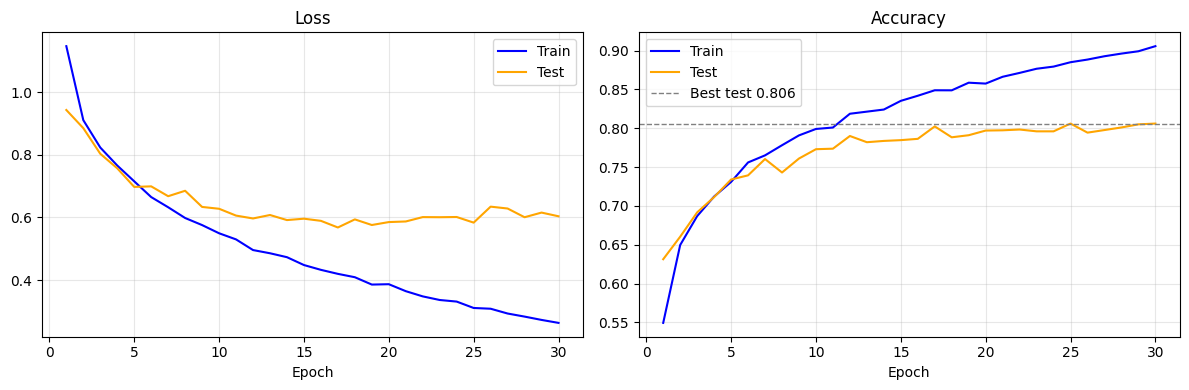

In [6]:
# Обучение

epochs = 30
lr = 3e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total

best_test_acc = 0.0
for epoch in range(1, epochs + 1):
    model.train()
    train_loss, correct, total = 0.0, 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * len(labels)
        correct += (logits.argmax(1) == labels).sum().item()
        total += len(labels)

    train_loss /= total
    train_acc = correct / total
    test_loss, test_acc = evaluate(test_loader)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_xlstm_intel_hw4.pth")

    if epoch % 5 == 0 or epoch == 1:
        print(f"[{epoch:3d}/{epochs}]"
              f"train loss={train_loss:.4f} acc={train_acc:.3f} | "
              f"test loss={test_loss:.4f} acc={test_acc:.3f}")

print(f"Лучшая точность на test: {best_test_acc:.3f}")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, epochs + 1)

axes[0].plot(ep, history["train_loss"], label="Train", color = "blue")
axes[0].plot(ep, history["test_loss"], label="Test", color="orange")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep, history["train_acc"], label="Train", color = "blue")
axes[1].plot(ep, history["test_acc"], label="Test", color="orange")
axes[1].axhline(best_test_acc, color="gray", ls="--", lw=1, label=f"Best test {best_test_acc:.3f}")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Визуализация гейтов

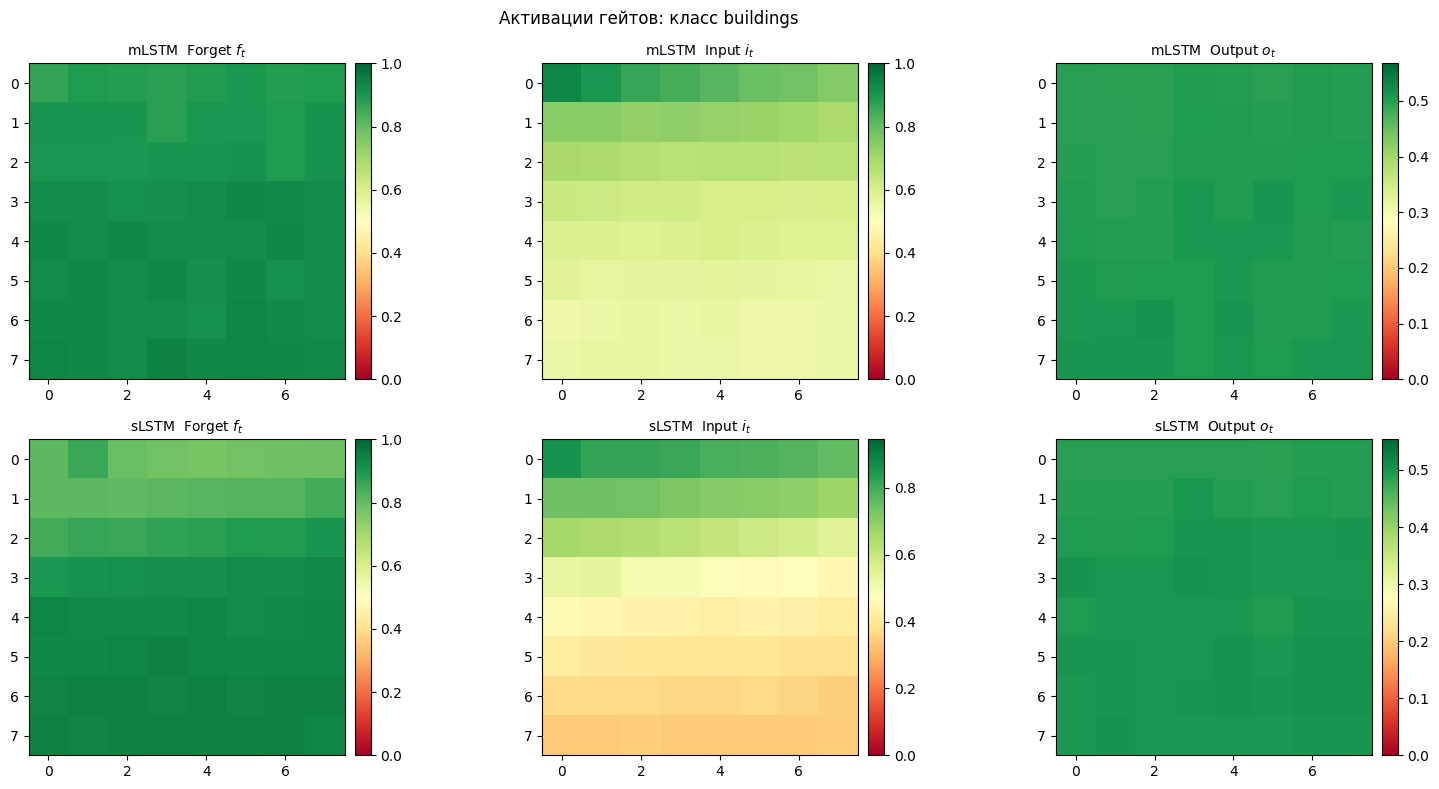

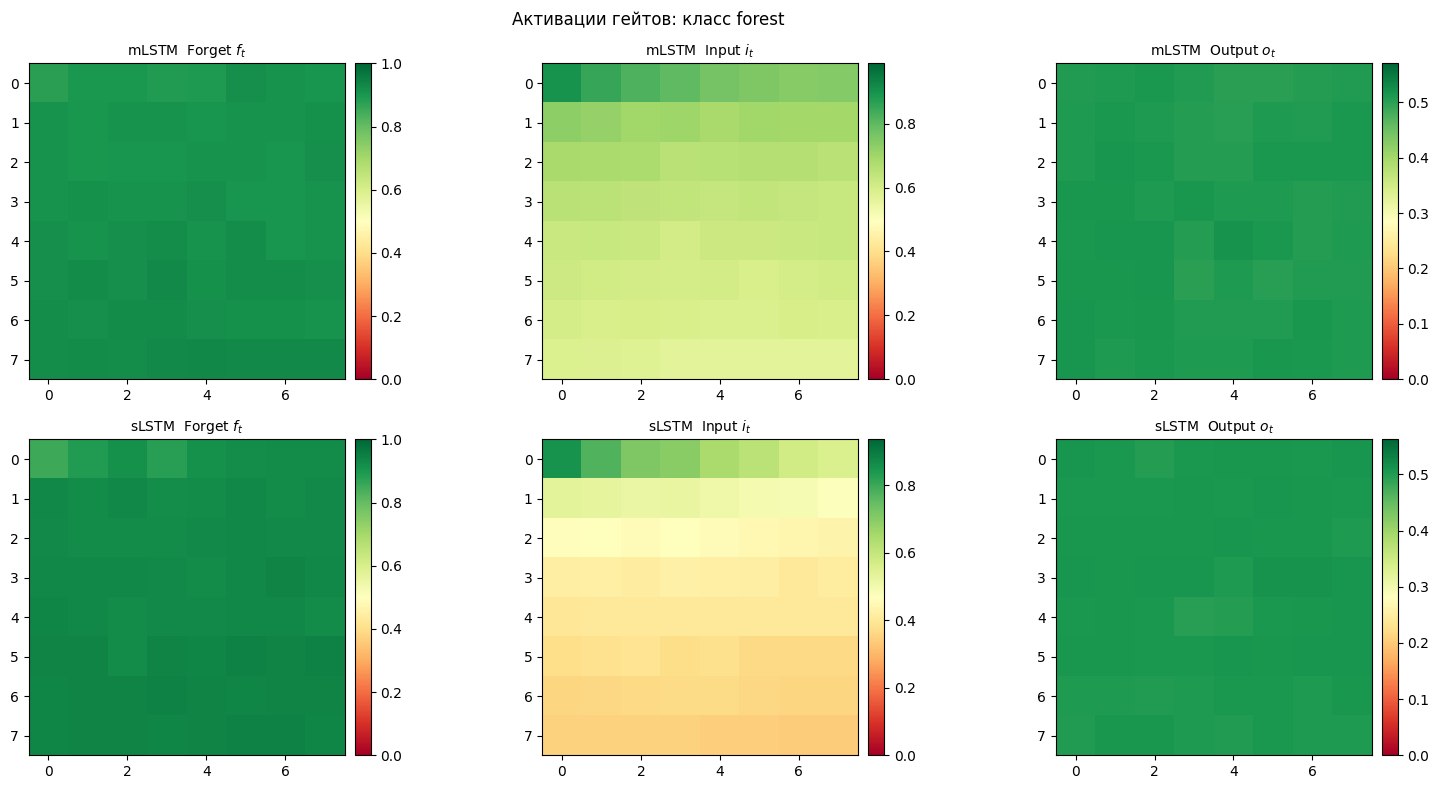

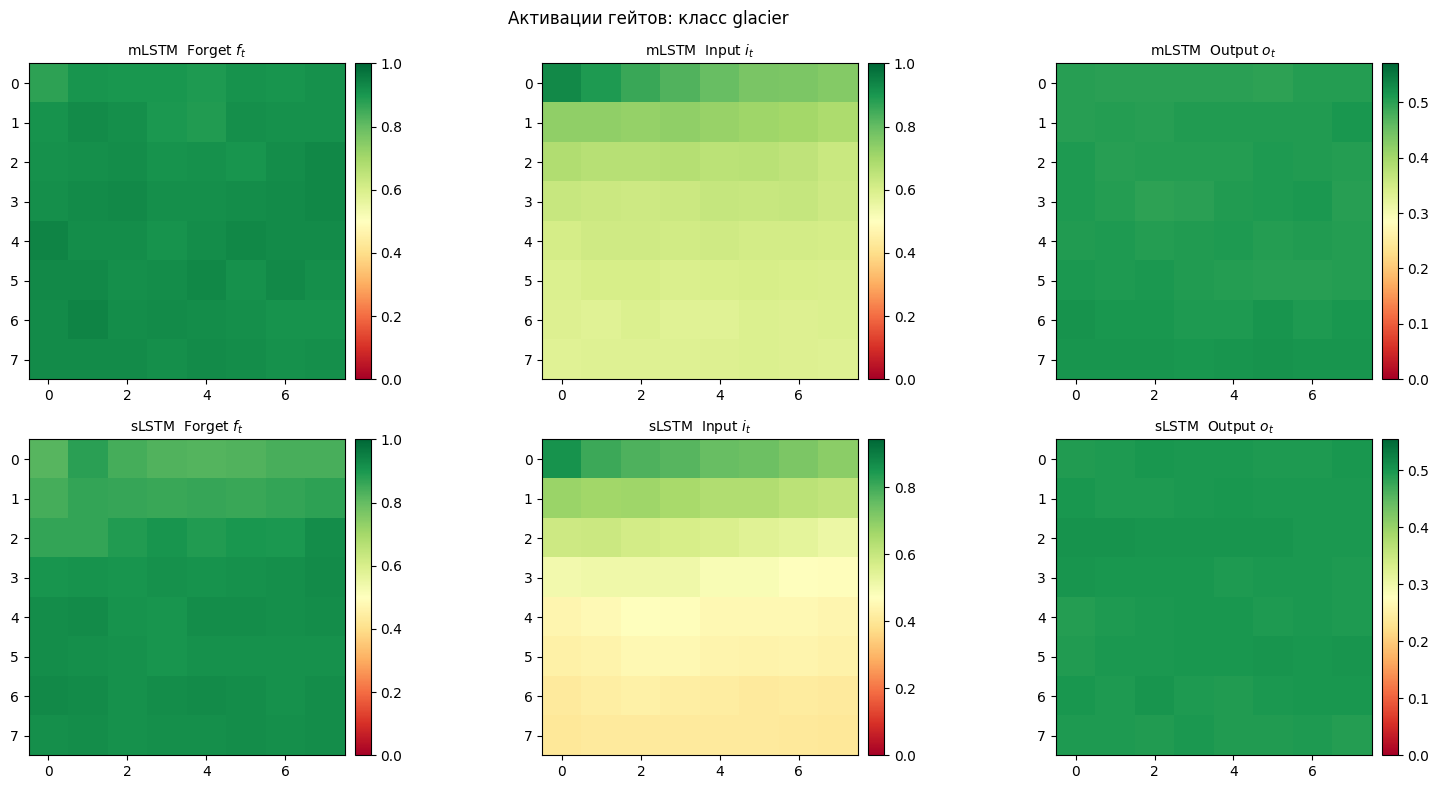

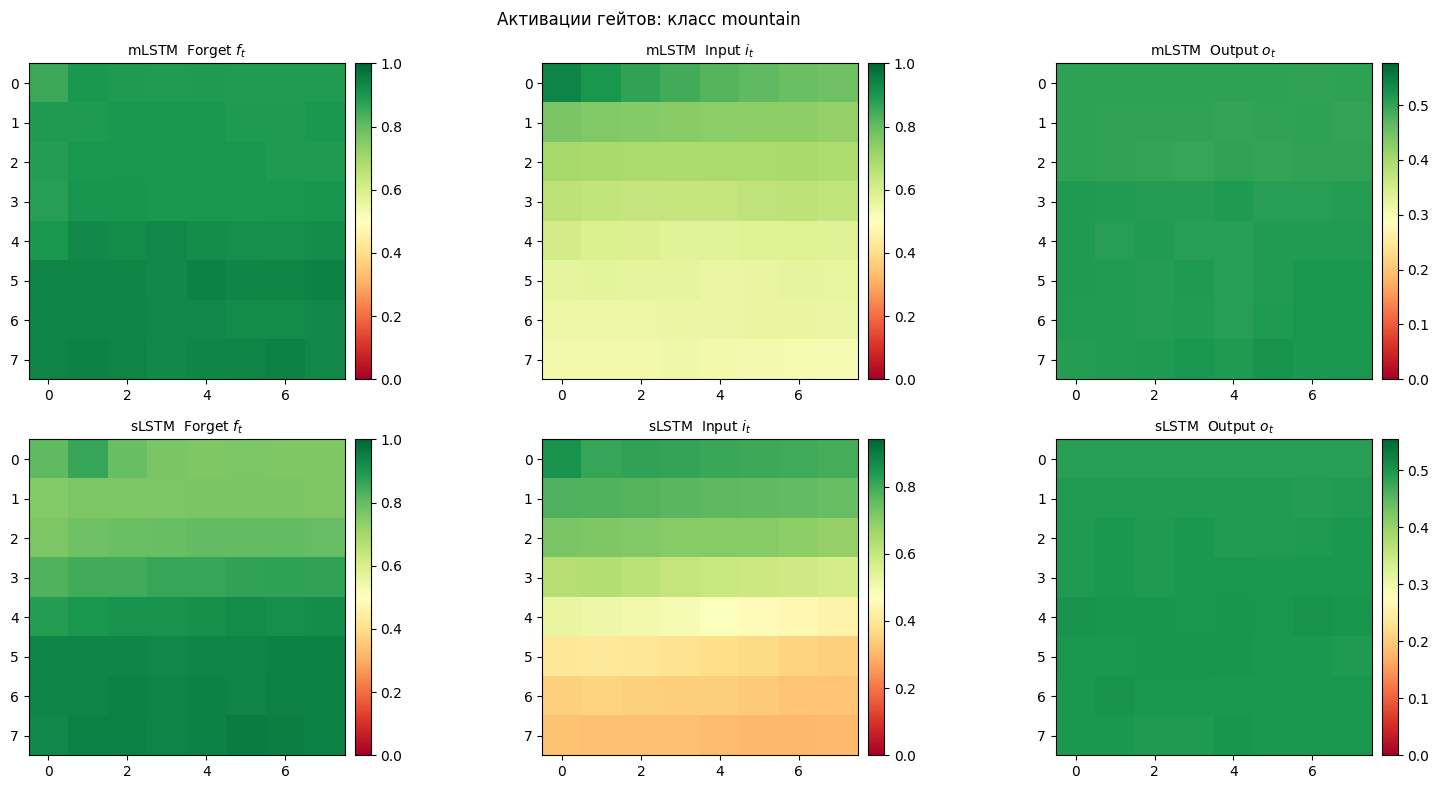

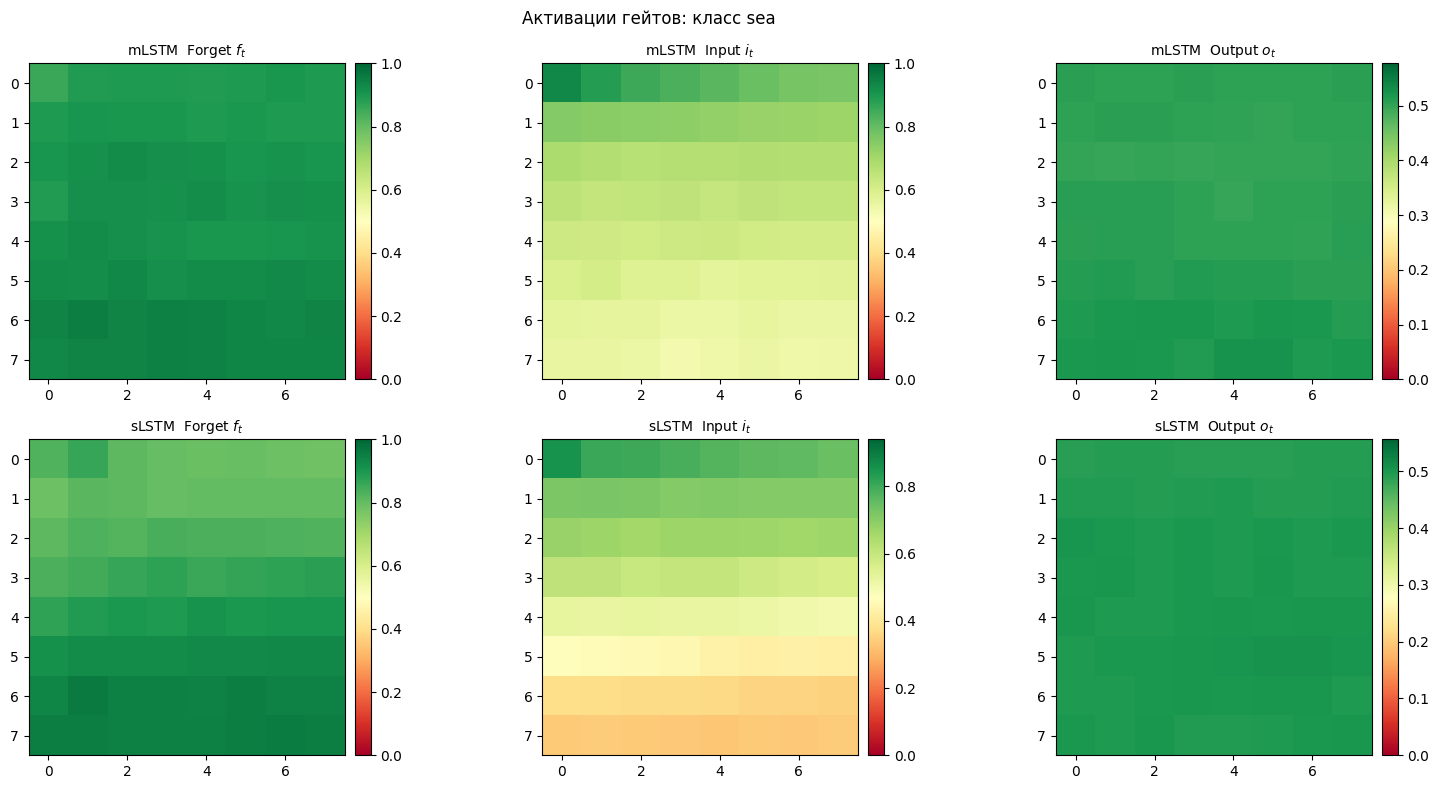

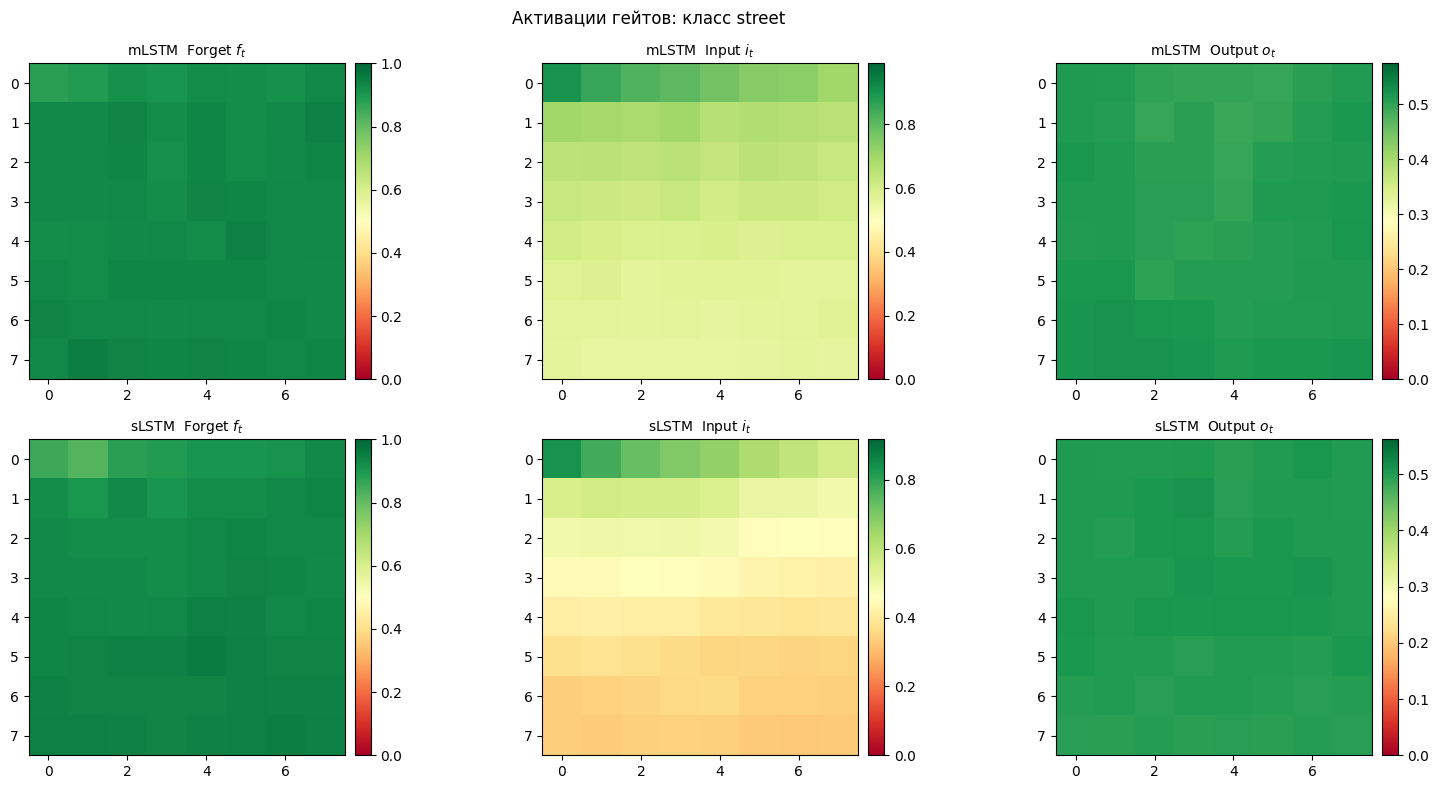

In [7]:
model.load_state_dict(torch.load("best_xlstm_intel_hw4.pth", map_location=device))
model.eval()

def get_gates(cls_label, n=8):
    imgs = torch.stack([test_ds[i][0] for i, (_, l) in enumerate(test_ds) if l == cls_label][:n]).to(device)
    with GateCapture(model.xlstm) as gc:
        with torch.no_grad():
            model(imgs)
        return gc.get_stacked()

def plot_gates(gates, class_name):
    layer_names = ["mLSTM", "sLSTM"]
    gate_keys = ["f", "i", "o"]
    gate_labels = ["Forget $f_t$", "Input $i_t$", "Output $o_t$"]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for l in range(2):
        for g in range(3):
            avg = gates[l][gate_keys[g]].mean(dim=(1, 2)).numpy()
            spatial = avg.reshape(img_size // patch_size, img_size // patch_size)
            im = axes[l, g].imshow(spatial, cmap="RdYlGn", vmin=0, vmax=min(1.0, avg.max() * 1.1))
            axes[l, g].set_title(f"{layer_names[l]}  {gate_labels[g]}", fontsize=10)
            plt.colorbar(im, ax=axes[l, g], fraction=0.04, pad=0.02)
    plt.suptitle(f"Активации гейтов: класс {class_name}", fontsize=12)
    plt.tight_layout()
    plt.show()

for cls in range(n_classes):
    plot_gates(get_gates(cls), class_names_list[cls])

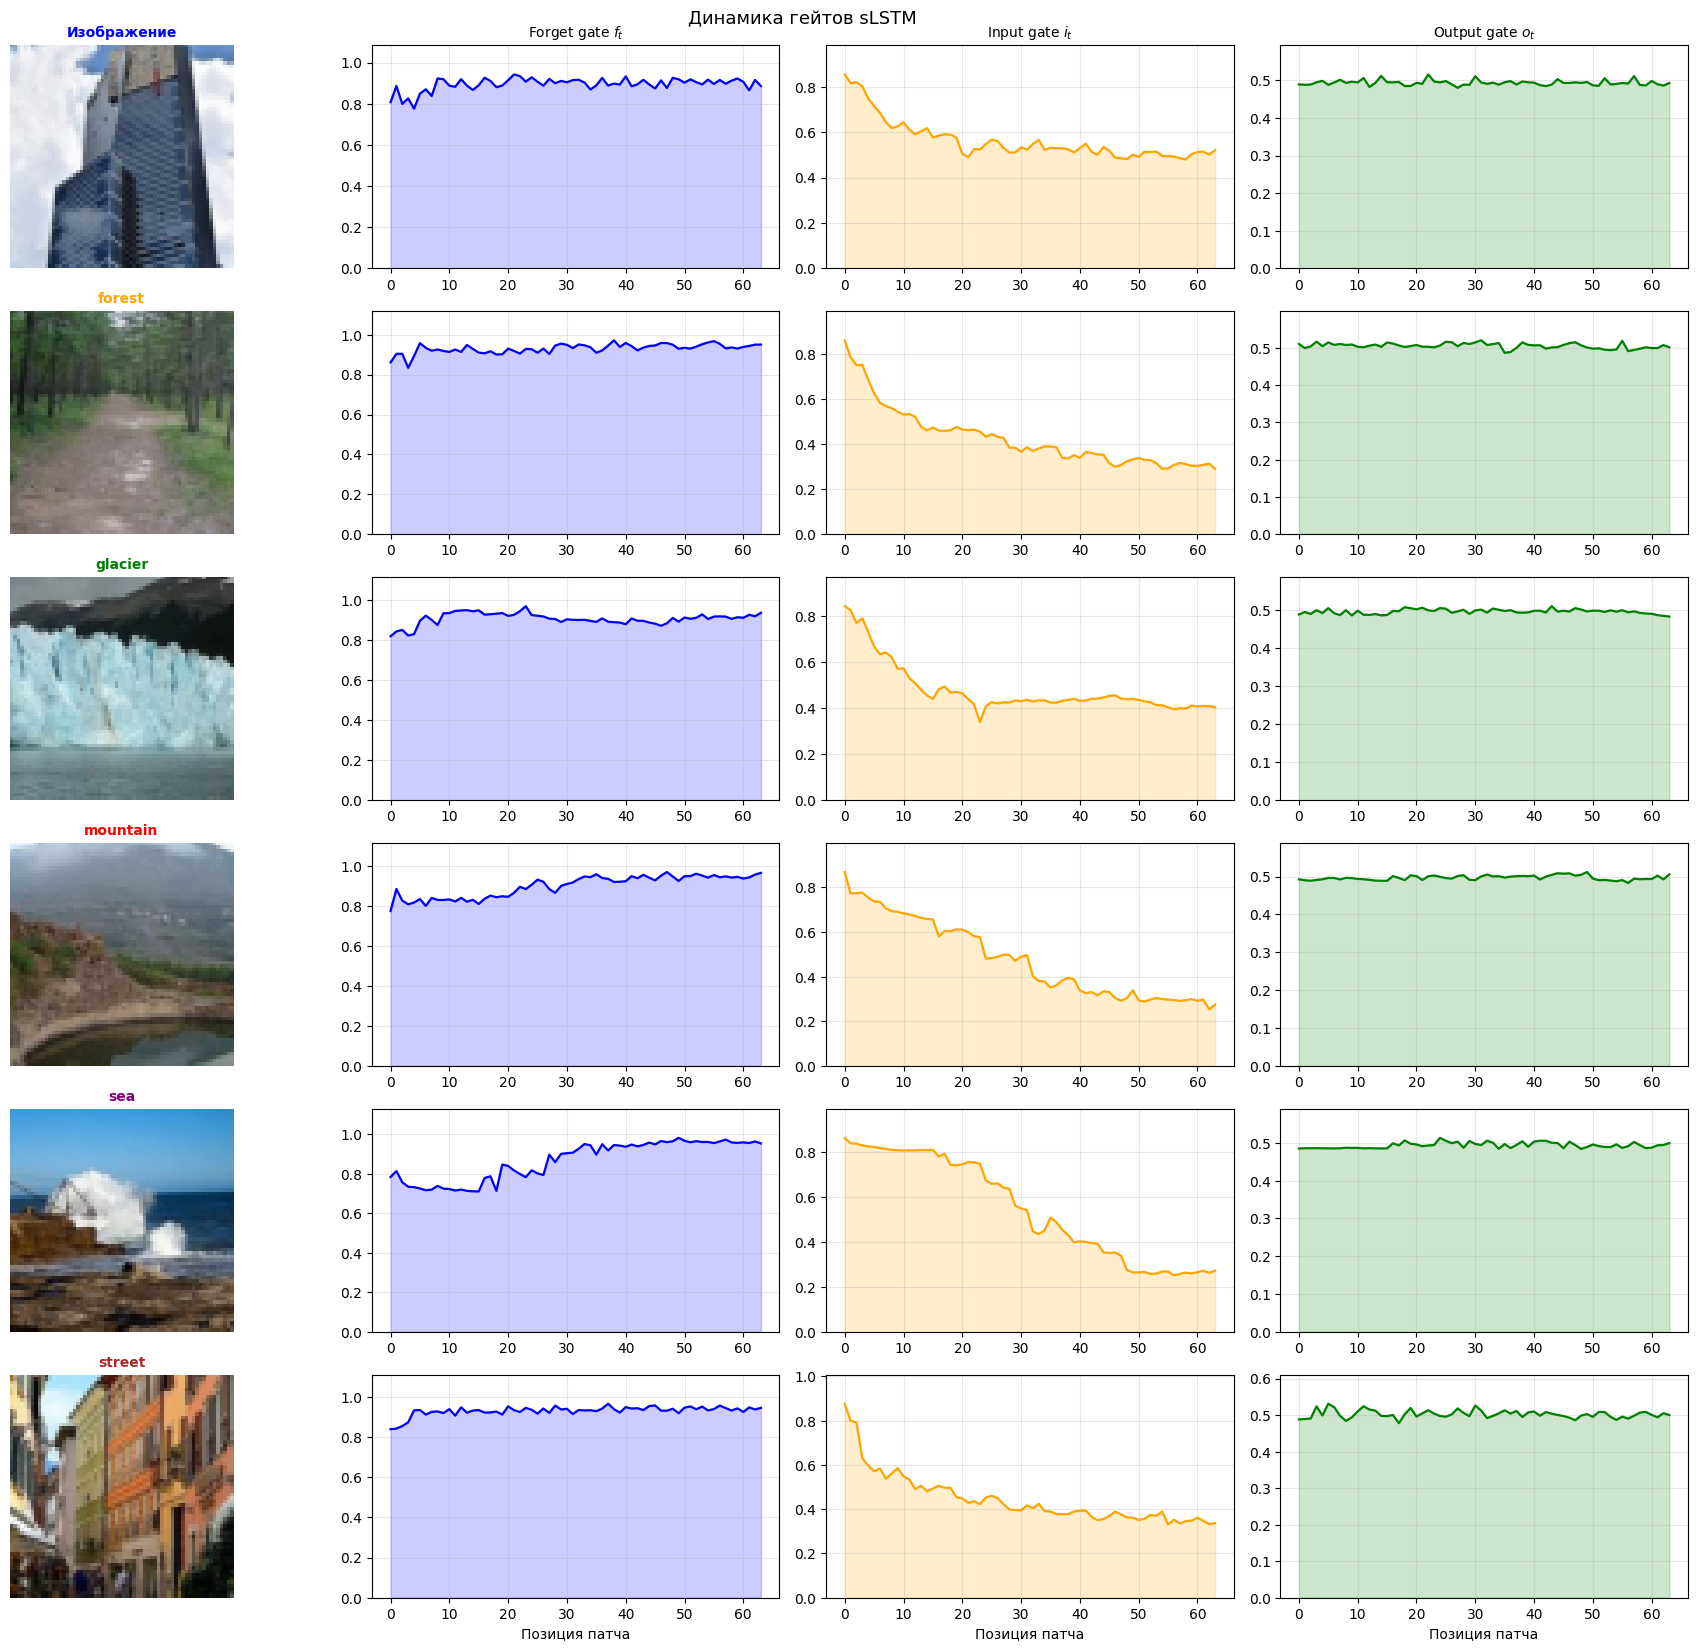

In [8]:
inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)

fig, axes = plt.subplots(n_classes, 4, figsize=(18, n_classes * 2.8))

gate_colors = {"f": "blue", "i": "orange", "o": "green"}
gate_titles = {"f": "Forget gate $f_t$", "i": "Input gate $i_t$", "o": "Output gate $o_t$"}
layer_idx = 1   # sLSTM (слой 2)

for cls in range(n_classes):
    idx = next(i for i, (_, l) in enumerate(test_ds) if l == cls)
    img_t, _ = test_ds[idx]
    img_show = inv_norm(img_t).permute(1, 2, 0).clip(0, 1).numpy()

    imgs_b = img_t.unsqueeze(0).to(device)
    with GateCapture(model.xlstm) as gc:
        with torch.no_grad():
            _ = model(imgs_b)
        gates_all = gc.get_stacked()

    patch_axis = np.arange(n_patches)

    # Изображение
    axes[cls, 0].imshow(img_show)
    axes[cls, 0].set_title(f"{class_names_list[cls]}", fontsize=10, color=colors[cls], fontweight="bold")
    axes[cls, 0].axis("off")

    # Гейты
    for col, gk in enumerate(["f", "i", "o"], start=1):
        vals = gates_all[layer_idx][gk][:, 0, :].mean(-1).numpy()
        axes[cls, col].plot(patch_axis, vals, color=gate_colors[gk], lw=1.6)
        axes[cls, col].fill_between(patch_axis, 0, vals, alpha=0.2, color=gate_colors[gk])
        axes[cls, col].set_ylim(0, max(vals.max() * 1.15, 0.05))
        axes[cls, col].set_title(gate_titles[gk] if cls == 0 else "", fontsize=10)
        axes[cls, col].grid(alpha=0.3)
        if cls == n_classes - 1:
            axes[cls, col].set_xlabel("Позиция патча")

axes[0, 0].set_title("Изображение", fontsize=10, fontweight="bold")
plt.suptitle("Динамика гейтов sLSTM", fontsize=13)
plt.tight_layout()
plt.show()


## Выводы

### 1. Обучение

Модель Vision-xLSTM (ms, hidden=128) достигла 80.6% точности на test за 30 эпох

| Эпоха | Train loss | Train acc | Test loss | Test acc |
|------:|----------:|----------:|---------:|--------:|
| 1 | 1.1467 | 54.9% | 0.943 | 63.1% |
| 5 | 0.715 | 73.1% | 0.697 | 73.4% |
| 10 | 0.549 | 79.9% | 0.627 | 77.3% |
| 15 | 0.448 | 83.5% | 0.596 | 78.5% |
| 20 | 0.387 | 85.7% | 0.585 | 79.7% |
| 25 | 0.311 | 88.5% | 0.583 | 80.6% |
| 30 | 0.263 | 90.6% | 0.603 | 80.6% |

После эпохи ~15 test loss перестал снижаться (плато ~0.64–0.68), тогда как train loss продолжал падать.

### 2. Визуализация гейтов (тепловые карты)

#### Forget gate $f_t$
Равномерно высокий (~0.8–1.0) у почти всех шести классов в обоих слоях (mLSTM и sLSTM). Модель практически никогда не забывает — накопленная матрица памяти сохраняется на всём протяжении последовательности.

#### Input gate $i_t$
Одинаковый паттерн у всех классов: верхние строки патчей (строки 0–1) имеют максимальную активность (~0.8–1.0), нижние строки (6–7) — минимальную (~0.0–0.2). Патчи в начале последовательности (верх изображения) обрабатываются при пустом контексте, поэтому $i_t$ высокий. К концу последовательности контекст уже наполнен, и модель полагается на накопленное $C_t$.

#### Output gate $o_t$
Полностью равномерный (~0.4–0.5) у всех классов. Не несёт никакой информации о классе.

### 3. Динамика гейтов по позициям патчей (sLSTM, слой 2) (Примерно те же выводы)

На линейных графиках (слева направо, сверху вниз):

Forget gate $f_t$: у всех классов, кроме sea, стабилен ~0.8–1.0 вдоль всей последовательности. Кривая практически горизонтальная — модель никогда не сбрасывает контекст.

Input gate $i_t$: монотонно убывает от ~0.8 в начале до ~0.2–0.3 к концу последовательности. Паттерн одинаков для всех классов. 

Output gate $o_t$: практически плоский ~0.5 по всем 64 позициям у всех классов.

Итог: гейты в данной архитектуре отражают динамику заполнения памяти, а не характер изображения. Классы различаются значениями внутри $C_t$, а не паттернами гейтов.